<a href="https://colab.research.google.com/github/Mohammed-Saif-07/ML-winter-quarter/blob/main/EX10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Load MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

print("Dataset shape:", X.shape)

Dataset shape: (70000, 784)


In [3]:
# First 60,000 = training
X_train = X[:60000]
y_train = y[:60000]

# Remaining 10,000 = test
X_test = X[60000:]
y_test = y[60000:]

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (60000, 784)
Test set: (10000, 784)


In [4]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

start = time.time()
rf.fit(X_train, y_train)
rf_train_time = time.time() - start

print("Random Forest Training Time (Full Data):", rf_train_time)

Random Forest Training Time (Full Data): 57.234944343566895


In [5]:
y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9705

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [6]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Original shape:", X_train.shape)
print("Reduced shape:", X_train_pca.shape)

Original shape: (60000, 784)
Reduced shape: (60000, 154)


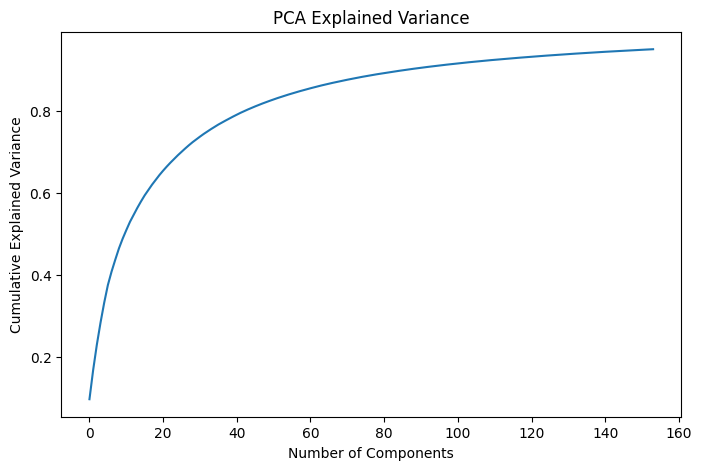

In [7]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

In [8]:
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)

start = time.time()
rf_pca.fit(X_train_pca, y_train)
rf_pca_train_time = time.time() - start

print("Random Forest Training Time (PCA Data):", rf_pca_train_time)

Random Forest Training Time (PCA Data): 187.76444673538208


In [9]:
y_pred_rf_pca = rf_pca.predict(X_test_pca)

rf_pca_accuracy = accuracy_score(y_test, y_pred_rf_pca)

print("Random Forest Accuracy with PCA:", rf_pca_accuracy)

Random Forest Accuracy with PCA: 0.9488


In [10]:
sgd = SGDClassifier(random_state=42)

start = time.time()
sgd.fit(X_train, y_train)
sgd_train_time = time.time() - start

print("SGD Training Time (Full Data):", sgd_train_time)

SGD Training Time (Full Data): 190.26806664466858


In [11]:
y_pred_sgd = sgd.predict(X_test)

sgd_accuracy = accuracy_score(y_test, y_pred_sgd)

print("SGD Accuracy:", sgd_accuracy)

SGD Accuracy: 0.874


In [12]:
sgd_pca = SGDClassifier(random_state=42)

start = time.time()
sgd_pca.fit(X_train_pca, y_train)
sgd_pca_train_time = time.time() - start

print("SGD Training Time (PCA Data):", sgd_pca_train_time)

SGD Training Time (PCA Data): 42.742297887802124


In [13]:
y_pred_sgd_pca = sgd_pca.predict(X_test_pca)

sgd_pca_accuracy = accuracy_score(y_test, y_pred_sgd_pca)

print("SGD Accuracy with PCA:", sgd_pca_accuracy)

SGD Accuracy with PCA: 0.8959


In [14]:
sgd_pca = SGDClassifier(random_state=42)

start = time.time()
sgd_pca.fit(X_train_pca, y_train)
sgd_pca_train_time = time.time() - start

print("SGD Training Time (PCA Data):", sgd_pca_train_time)

SGD Training Time (PCA Data): 43.2586944103241


In [15]:
y_pred_sgd_pca = sgd_pca.predict(X_test_pca)

sgd_pca_accuracy = accuracy_score(y_test, y_pred_sgd_pca)

print("SGD Accuracy with PCA:", sgd_pca_accuracy)

SGD Accuracy with PCA: 0.8959


In [16]:
from xgboost import XGBClassifier

In [17]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

start = time.time()
xgb.fit(X_train, y_train)
xgb_train_time = time.time() - start

print("XGBoost Training Time (Full Data):", xgb_train_time)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:59:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Training Time (Full Data): 795.8121340274811


In [18]:
y_pred_xgb = xgb.predict(X_test)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.978


In [19]:
xgb_pca = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

start = time.time()
xgb_pca.fit(X_train_pca, y_train)
xgb_pca_train_time = time.time() - start

print("XGBoost Training Time (PCA Data):", xgb_pca_train_time)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:13:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Training Time (PCA Data): 202.07090210914612


In [20]:
y_pred_xgb_pca = xgb_pca.predict(X_test_pca)

xgb_pca_accuracy = accuracy_score(y_test, y_pred_xgb_pca)

print("XGBoost Accuracy with PCA:", xgb_pca_accuracy)

XGBoost Accuracy with PCA: 0.9618


In [21]:
print("==== MODEL COMPARISON ====\n")

print("Random Forest (Full Data)")
print("Training Time:", rf_train_time)
print("Accuracy:", rf_accuracy)

print("\nRandom Forest (PCA)")
print("Training Time:", rf_pca_train_time)
print("Accuracy:", rf_pca_accuracy)

print("\nSGD (Full Data)")
print("Training Time:", sgd_train_time)
print("Accuracy:", sgd_accuracy)

print("\nSGD (PCA)")
print("Training Time:", sgd_pca_train_time)
print("Accuracy:", sgd_pca_accuracy)

print("\nXGBoost (Full Data)")
print("Training Time:", xgb_train_time)
print("Accuracy:", xgb_accuracy)

print("\nXGBoost (PCA)")
print("Training Time:", xgb_pca_train_time)
print("Accuracy:", xgb_pca_accuracy)

==== MODEL COMPARISON ====

Random Forest (Full Data)
Training Time: 57.234944343566895
Accuracy: 0.9705

Random Forest (PCA)
Training Time: 187.76444673538208
Accuracy: 0.9488

SGD (Full Data)
Training Time: 190.26806664466858
Accuracy: 0.874

SGD (PCA)
Training Time: 43.2586944103241
Accuracy: 0.8959

XGBoost (Full Data)
Training Time: 795.8121340274811
Accuracy: 0.978

XGBoost (PCA)
Training Time: 202.07090210914612
Accuracy: 0.9618


In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.show()

Random forest + PCA

<Figure size 800x600 with 0 Axes>

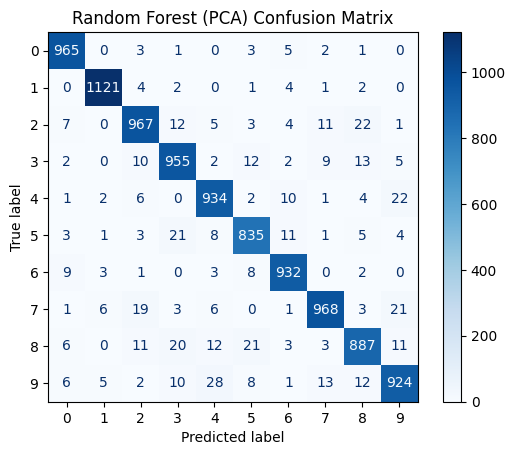

In [24]:
plot_confusion(y_test, y_pred_rf_pca, "Random Forest (PCA) Confusion Matrix")

SGD + PCA

<Figure size 800x600 with 0 Axes>

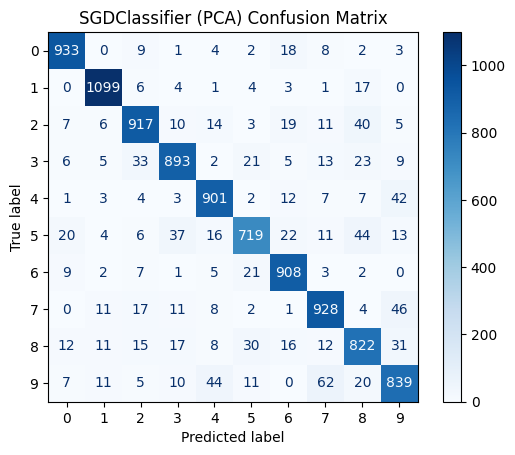

In [25]:
plot_confusion(y_test, y_pred_sgd_pca, "SGDClassifier (PCA) Confusion Matrix")

xgboost + PCA

<Figure size 800x600 with 0 Axes>

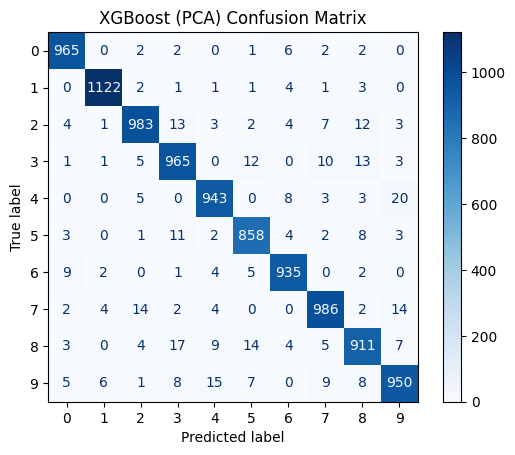

In [26]:
plot_confusion(y_test, y_pred_xgb_pca, "XGBoost (PCA) Confusion Matrix")

In [27]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Random Forest + PCA",
        "SGDClassifier",
        "SGDClassifier + PCA",
        "XGBoost",
        "XGBoost + PCA"
    ],
    "Accuracy": [
        rf_accuracy,
        rf_pca_accuracy,
        sgd_accuracy,
        sgd_pca_accuracy,
        xgb_accuracy,
        xgb_pca_accuracy
    ],
    "Training Time (s)": [
        rf_train_time,
        rf_pca_train_time,
        sgd_train_time,
        sgd_pca_train_time,
        xgb_train_time,
        xgb_pca_train_time
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Training Time (s)
4,XGBoost,0.9780,795.812134
0,Random Forest,0.9705,57.234944
5,XGBoost + PCA,0.9618,202.070902
1,Random Forest + PCA,0.9488,187.764447
3,SGDClassifier + PCA,0.8959,43.258694
2,SGDClassifier,0.8740,190.268067


q1. Was training significantly faster? How did performance compare to the  baseline?


Training speed changed depending on the model. With SGDClassifier, training became much faster after applying PCA, dropping from about 190 seconds to about 43 seconds. Accuracy also improved slightly from 0.874 to 0.8959, showing that PCA helped the model both in speed and performance. For XGBoost, PCA also reduced training time significantly (~796 seconds to ~202 seconds), but accuracy decreased slightly (0.978 to 0.9618). However, Random Forest behaved differently: training actually became slower with PCA (57s → 188s) and accuracy dropped (0.9705 → 0.9488).

q2. How much does PCA help SGDClassifier compared to Random Forest? Why might the effect differ?


PCA helped SGDClassifier much more than Random Forest. SGD is a linear model that benefits from fewer, less redundant features, so reducing dimensionality from 784 to 154 features made optimization faster and slightly improved accuracy. In contrast, Random Forest is a tree-based model that already handles high-dimensional data well and relies on original feature splits. When PCA transforms the features into new components, it may remove useful structure, which can reduce accuracy and even increase training time. This shows that PCA is generally more beneficial for linear models than for tree-based models.

**Reflection**

From this exercise, I learned that PCA can be very beneficial when working with high-dimensional data, but its effectiveness depends heavily on the type of model used. Linear models like SGDClassifier benefit more from dimensionality reduction because fewer features simplify the optimization process. In contrast, tree-based models such as Random Forest already handle high-dimensional data well and rely on feature splits, so transforming features with PCA may remove useful structure and slightly reduce performance. Overall, PCA can greatly reduce dimensionality and training cost, but it may come with trade-offs in accuracy, and its usefulness depends on the model and dataset.